In [36]:
import pandas as pd
from glob import glob

In [38]:
files = glob('../intermed_results/*.csv')

In [39]:
files = sorted(files)

In [40]:
synthesizers = list(set(['_'.join(file.split('/')[-1].split('.')[0].split('_')[:-1]) for file in files]))

In [41]:
synthesizers = [
    'adsgan',
    'pategan',
    'dpgan',
    'decaf',
    'nflow',
    'marginal_distributions',
    'uniform_sampler',
    'ctgan',
    'tvae',
    'dummy_sampler',
    'rtvae',
    'ddpm',
    'arf',
]

In [42]:
def prepare_results(synth_name):
    paths = [file for file in files if f'/{synth_name}_' in file]
    df_list = []
    for path in paths:
        temp = pd.read_csv(path)
        temp = temp[['index', 'median', 'privgen_used']]
        temp.columns = ['metric', 'value', 'privgen_used']
        df_list.append(temp)
    df = pd.concat(df_list)
    df['synthesizer'] = synth_name
    df_pivot = df.pivot(index=['metric', 'synthesizer'], columns='privgen_used', values='value')
    try:
        # Rename columns for clarity
        df_pivot.columns = ['Orig', 'PrivGen']

        # Reset index to keep 'metric' and 'synthesizer'
        df_pivot.reset_index(inplace=True)
        df_pivot = df_pivot[~df_pivot['metric'].str.endswith('.gt')]
        return df_pivot
    except Exception as e:
        print(e)

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the metrics direction table
metrics_direction = pd.read_excel("../metrics_direction_2.xlsx")  
metrics_direction = metrics_direction.set_index("metric")  # Set metric as index for quick lookup

<Figure size 1000x600 with 0 Axes>

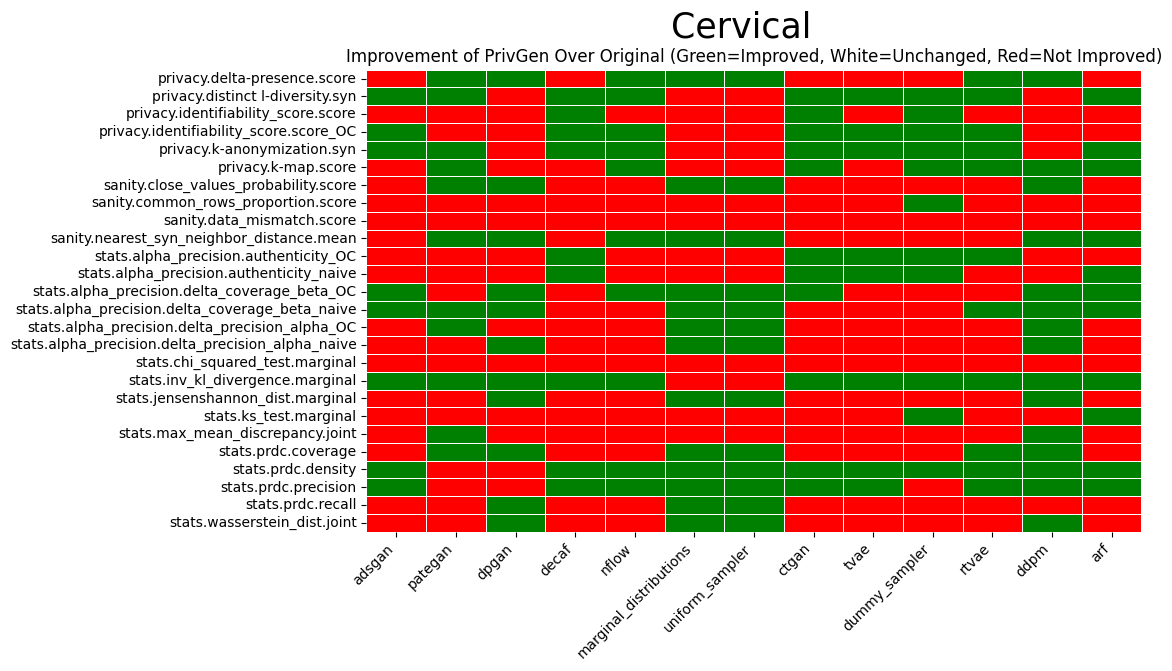

In [44]:
# List of synthesizer result files (replace with actual file names)
# synthesizer_files = [prepare_results(synth) for synth in synthesizers]

# Initialize an empty dictionary to store results
comparison_results = {}

for synth in synthesizers:
    # Load synthesizer table
    df = prepare_results(synth)

    # Extract synthesizer name from file (assuming filename format is "synth_name.csv")
    synthesizer_name = df['synthesizer'][0]

    # Initialize results storage
    comparison_results[synthesizer_name] = {}

    for _, row in df.iterrows():
        metric = row["metric"]
        orig_value = row["Orig"]
        privgen_value = row["PrivGen"]

        # Get direction from metrics_direction table
        if metric in metrics_direction.index:
            direction = metrics_direction.loc[metric, "Direction"]

            # Compare values based on direction
            if direction == "Min":
                improved = 1 if privgen_value < orig_value else 0
            elif direction == "Max":
                improved = 1 if privgen_value > orig_value else 0
            else:
                improved = 0  # Default to 0 if direction is unclear

            comparison_results[synthesizer_name][metric] = improved

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_results).fillna(
    0)  # Fill missing values with 0

# Plot heatmap
plt.figure(figsize=(10, 6))
import numpy as np
from matplotlib.colors import ListedColormap

# Define custom colormap: Red for no improvement, Green for improvement, White for unchanged
custom_cmap = ListedColormap(["red", "white", "green"])

# Convert to numpy for handling unchanged cases
comparison_array = comparison_df.to_numpy()

# Define new logic:
# -1 -> No improvement (Red)
#  0 -> Unchanged (White)
#  1 -> Improved (Green)
comparison_mapped = np.where(comparison_array == 1, 2,
                             np.where(comparison_array == 0, 1, 0))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(comparison_mapped,
            cmap=custom_cmap,
            annot=False,
            linewidths=0.5,
            cbar=False,
            xticklabels=comparison_df.columns,
            yticklabels=comparison_df.index)

plt.suptitle('Cervical', fontsize=25)
plt.title(
    "Improvement of PrivGen Over Original (Green=Improved, White=Unchanged, Red=Not Improved)"
)
plt.xticks(ticks=[i + 0.5 for i in range(len(comparison_df.columns))],
           labels=comparison_df.columns,
           rotation=45,
           ha='right')
plt.yticks(rotation=0)
plt.show()

Private models:
- AdsGAN
- PATEGAN
- DP-GAN
- DECAF

In [45]:
files = glob('../intermed_results/health/*.csv')

In [46]:
files = sorted(files)

<Figure size 1000x600 with 0 Axes>

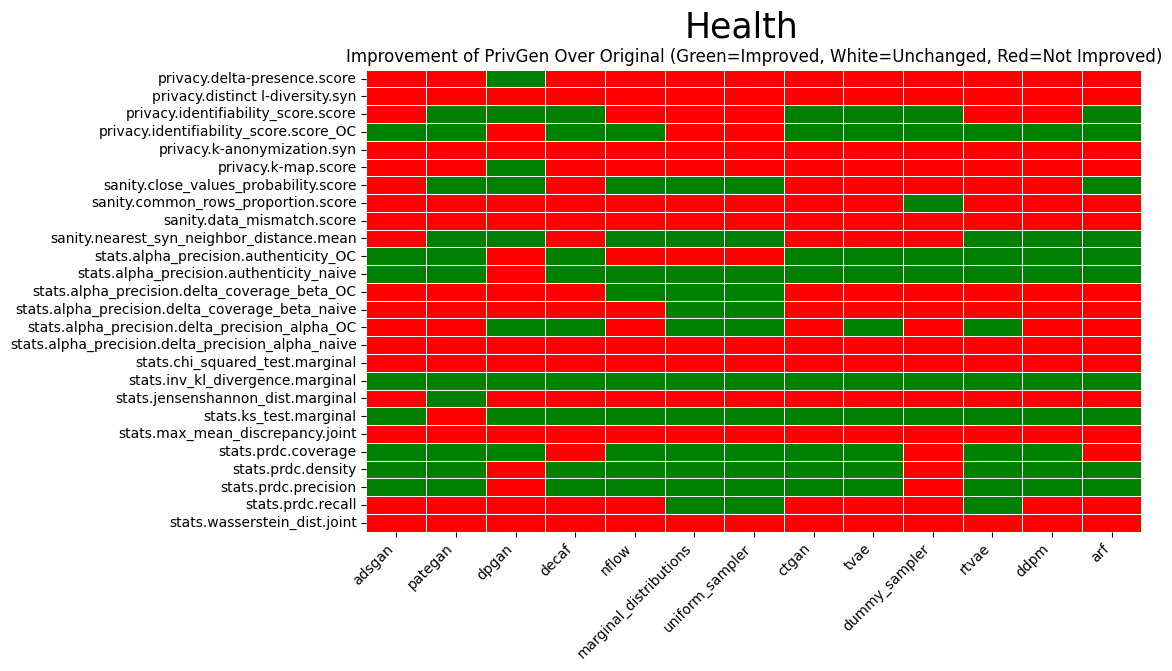

In [47]:
# List of synthesizer result files (replace with actual file names)
# synthesizer_files = [prepare_results(synth) for synth in synthesizers]

# Initialize an empty dictionary to store results
comparison_results = {}

for synth in synthesizers:
    # Load synthesizer table
    df = prepare_results(synth)

    # Extract synthesizer name from file (assuming filename format is "synth_name.csv")
    synthesizer_name = df['synthesizer'][0]

    # Initialize results storage
    comparison_results[synthesizer_name] = {}

    for _, row in df.iterrows():
        metric = row["metric"]
        orig_value = row["Orig"]
        privgen_value = row["PrivGen"]

        # Get direction from metrics_direction table
        if metric in metrics_direction.index:
            direction = metrics_direction.loc[metric, "Direction"]

            # Compare values based on direction
            if direction == "Min":
                improved = 1 if privgen_value < orig_value else 0
            elif direction == "Max":
                improved = 1 if privgen_value > orig_value else 0
            else:
                improved = 0  # Default to 0 if direction is unclear

            comparison_results[synthesizer_name][metric] = improved

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_results).fillna(
    0)  # Fill missing values with 0

# Plot heatmap
plt.figure(figsize=(10, 6))
import numpy as np
from matplotlib.colors import ListedColormap

# Define custom colormap: Red for no improvement, Green for improvement, White for unchanged
custom_cmap = ListedColormap(["red", "white", "green"])

# Convert to numpy for handling unchanged cases
comparison_array = comparison_df.to_numpy()

# Define new logic:
# -1 -> No improvement (Red)
#  0 -> Unchanged (White)
#  1 -> Improved (Green)
comparison_mapped = np.where(comparison_array == 1, 2,
                             np.where(comparison_array == 0, 1, 0))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(comparison_mapped,
            cmap=custom_cmap,
            annot=False,
            linewidths=0.5,
            cbar=False,
            xticklabels=comparison_df.columns,
            yticklabels=comparison_df.index)

plt.suptitle('Health', fontsize=25)
plt.title(
    "Improvement of PrivGen Over Original (Green=Improved, White=Unchanged, Red=Not Improved)"
)
plt.xticks(ticks=[i + 0.5 for i in range(len(comparison_df.columns))],
           labels=comparison_df.columns,
           rotation=45,
           ha='right')
plt.yticks(rotation=0)
plt.show()